# 项目名称 — 模块说明

| 项目   | 内容 |
|--------|------|
| 课程   | 数据分析与经济决策（ds2026） |
| 题目   | T-B2_美联储货币政策与全球资产价格传导 |
| 小组   | 第 4 组 |
| 成员   | 25210227 荣渝渝| 25210229 沈仕沐| 25210246 王丽娜| 25210257 吴玥| 25210271 连伊丽| 25210275 薛佳程| 25210285 易忠凯|
| GitHub | https://github.com/zhongerhenglu/ds2026-G04-T-B2_FedPolicyAssets |
| Pages  | https://zhongerhenglu.github.io/ds2026-G04-T-B2_FedPolicyAssets/ |
| 日期   | 2026-05-16 |

#  荣渝渝：任务 3a — 联邦基金利率历史可视化

✅ 数据读取成功！数据前5行预览：
            fedfunds      m2  pce_yoy
1993-01-31      3.02  3419.1      NaN
1993-02-28      3.03  3414.5      NaN
1993-03-31      3.07  3411.7      NaN
1993-04-30      2.96  3411.3      NaN
1993-05-31      3.00  3436.9      NaN

📊 数据时间范围：1993-01-31 至 2026-04-30

✅ 图表已保存到当前文件夹：fig_fed_rate_history.png


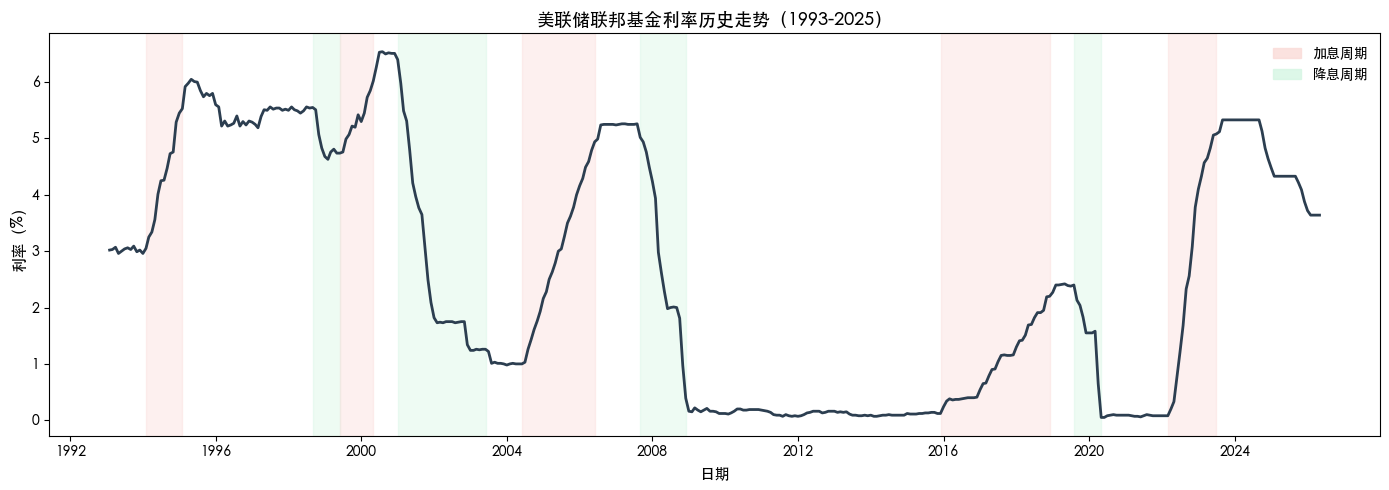

In [1]:

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

try:
    df = pd.read_csv(
        'fed_rates_raw.csv',
        index_col=0,       # 把第一列（日期列）设为数据索引
        parse_dates=True   # 自动解析日期格式，适配绘图
    )
 
    print("✅ 数据读取成功！数据前5行预览：")
    print(df.head())
    print(f"\n📊 数据时间范围：{df.index.min().date()} 至 {df.index.max().date()}")
except FileNotFoundError:
    print("❌ 错误：找不到 fed_rates_raw.csv 文件，请确保文件和笔记本在同一文件夹！")
except KeyError as e:
    print(f"❌ 错误：数据中找不到列 {e}，请检查 CSV 文件的列名是否为 'fedfunds'！")

cycles = [
    ('1994-02-01', '1995-02-01', 'hike'),
    ('1998-09-01', '1999-06-01', 'cut'),
    ('1999-06-01', '2000-05-01', 'hike'),
    ('2001-01-01', '2003-06-01', 'cut'),
    ('2004-06-01', '2006-06-01', 'hike'),
    ('2007-09-01', '2008-12-01', 'cut'),
    ('2015-12-01', '2018-12-01', 'hike'),
    ('2019-08-01', '2020-05-01', 'cut'),
    ('2022-03-01', '2023-07-01', 'hike'),
]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df.index, 
    df['fedfunds'], 
    color='#2c3e50', 
    linewidth=2,
    label='联邦基金利率'
)

for start_date, end_date, cycle_type in cycles:
    fill_color = '#fadbd8' if cycle_type == 'hike' else '#d5f5e3'
    ax.axvspan(
        pd.Timestamp(start_date),
        pd.Timestamp(end_date),
        alpha=0.4,
        color=fill_color,
        zorder=0  
    )

ax.set_title('美联储联邦基金利率历史走势（1993-2025）', fontsize=13, fontweight='medium')
ax.set_ylabel('利率（%）', fontsize=11)
ax.set_xlabel('日期', fontsize=11)

hike_patch = mpatches.Patch(color='#fadbd8', alpha=0.8, label='加息周期')
cut_patch = mpatches.Patch(color='#d5f5e3', alpha=0.8, label='降息周期')
ax.legend(handles=[hike_patch, cut_patch], loc='upper right', frameon=False)

plt.tight_layout()

plt.savefig('fig_fed_rate_history.png', dpi=150, bbox_inches='tight')
print("\n✅ 图表已保存到当前文件夹：fig_fed_rate_history.png")

plt.show()